In [1]:
import os, pathlib
#os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
#os.chdir("/Users/malpas.1/Code/SURP25/Microlensing")

In [2]:
from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
from ML import TwoLens1S
from ML import ThreeLens1S

In [ ]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
#u0_list =[-0.018, -0.020] #paper
u0_list =[0.018, 0.020] #paper

t0 = 0
tE = 20
rho = 0.0018
rs = rho

secnum = 45
basenum = 2
num_points = 1000

In [4]:
#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 0, psi, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_rad,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag

Text(0.5, 1.0, 'Triple Lens Light Curve (high-res)')

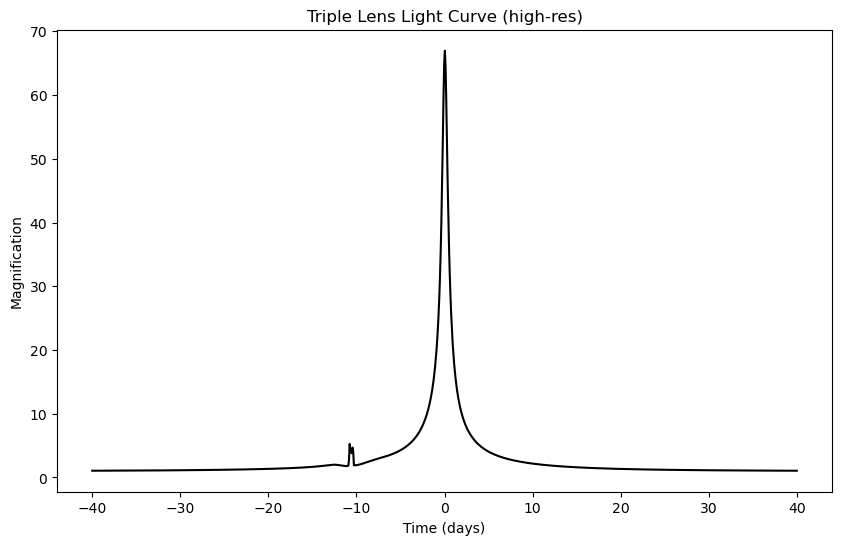

In [23]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_t, triple_model_mag, 'k-')
plt.xlabel('Time (days)')
plt.ylabel('Magnification')
plt.title('Triple Lens Light Curve (high-res)')

(-12.0, -10.0)

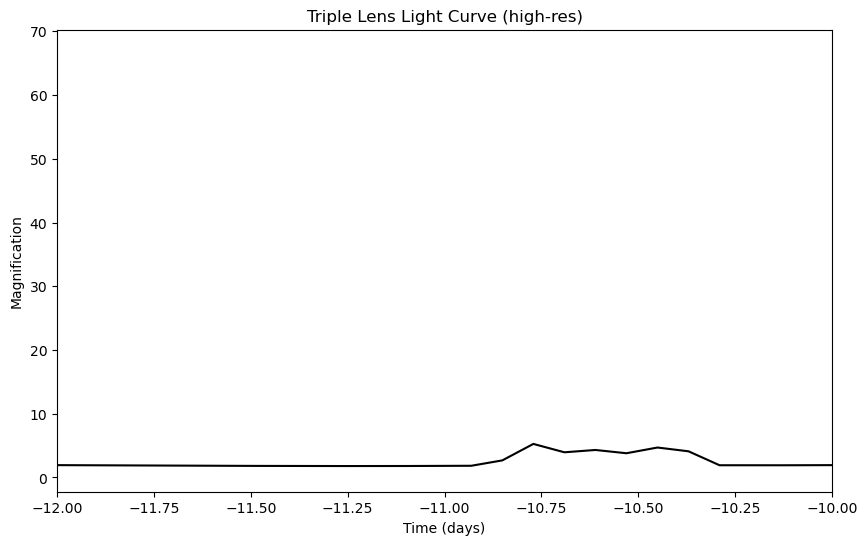

In [24]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_t, triple_model_mag, 'k-')
plt.xlabel('Time (days)')
plt.ylabel('Magnification')
plt.title('Triple Lens Light Curve (high-res)')
plt.xlim((-12, -10))


u0=0.018 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.018 -0.018 -0.018 -0.018 -0.018]
u0=0.018 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.018 -0.018 -0.018 -0.018 -0.018]
u0=0.02 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.02 -0.02 -0.02 -0.02 -0.02]
u0=0.02 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.02 -0.02 -0.02 -0.02 -0.02]


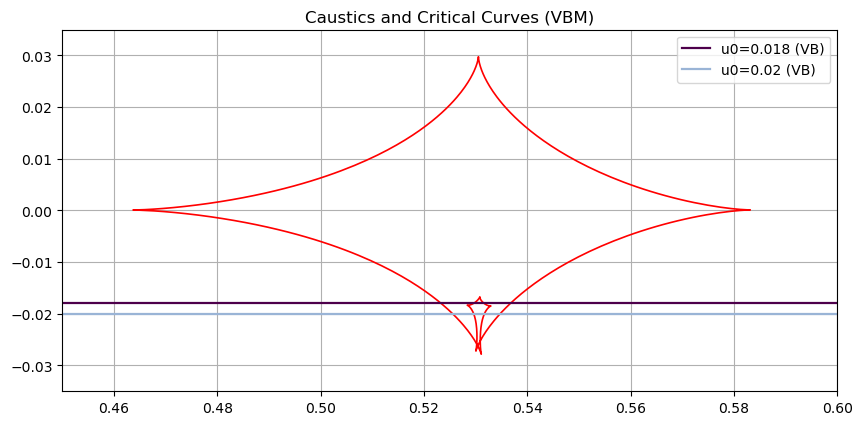

In [7]:
triple_model.plot_caustics_and_critical(show = False)
ax = plt.gca()
ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.035, 0.035)
plt.show()

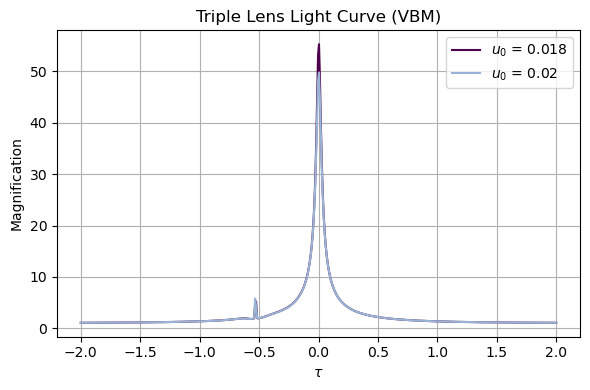

In [8]:
triple_model.plot_light_curve(max_points=100)

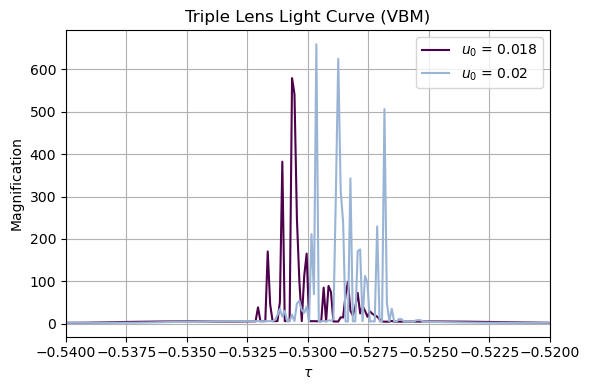

In [9]:
triple_model.plot_light_curve(trange=(-0.54, -0.52), max_points=200)

# New Set Example

In [1]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
import ML_amber, inspect, sys, importlib

from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
print("Imported ML.py from:", ML_amber.__file__)

Imported ML.py from: /Users/gregcc/Documents/GitHub/SURP25/Microlensing/ML_amber.py


In [2]:
from ML_amber import ThreeLens1S
from ML_amber import TwoLens1S

In [36]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[0.0155] #paper

t0 = 0
tE = 20
rho = 1.8e-3
rs = rho

secnum = 45
basenum = 2
num_points = 50000

In [37]:
#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 0, psi, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag



In [48]:
#binary system
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 0, t_lc= triple_model.highres_t )
A_bin = double_model.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

binary_model = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 0, t_lc= triple_model.highres_t )
B_bin = binary_model.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

(0.0, 10.0)

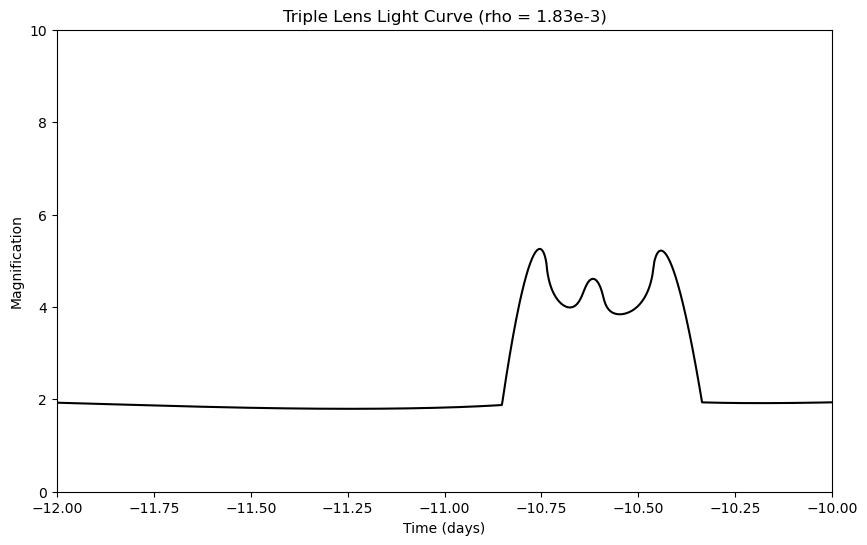

In [49]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_t, triple_model_mag, 'k-')

plt.xlabel('Time (days)')
plt.ylabel('Magnification')
plt.title('Triple Lens Light Curve (rho = 1.83e-3)')
plt.xlim((-12, -10))
plt.ylim((0, 10))

(0.0, 10.0)

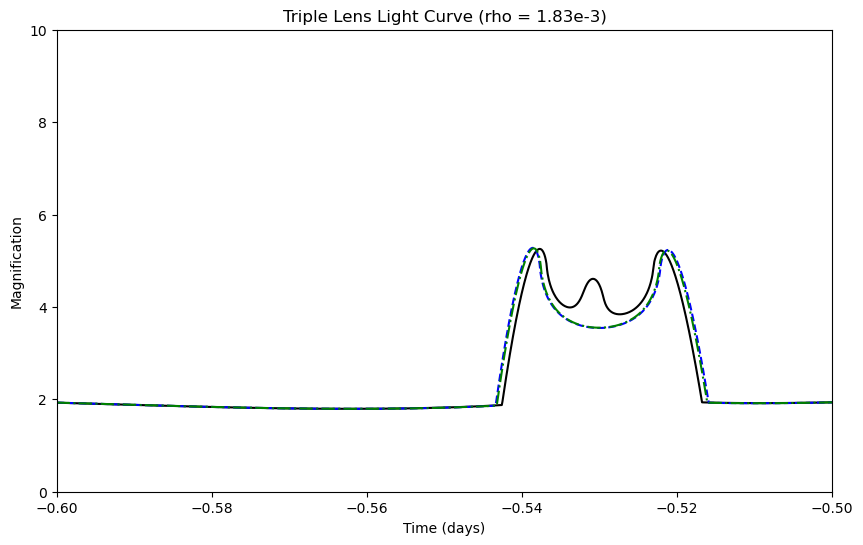

In [50]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_tau, triple_model_mag, 'k-')
plt.plot(triple_model_tau, A_bin, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau, B_bin, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel('Time (days)')
plt.ylabel('Magnification')
plt.title('Triple Lens Light Curve (rho = 1.83e-3)')
plt.xlim((-0.6, -0.5))
plt.ylim((0, 10))

u0=0.0155 VB y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.0155 -0.0155 -0.0155 -0.0155 -0.0155]
u0=0.0155 analytic y1[:5]=[2.         1.98997494 1.97994987 1.96992481 1.95989975] y2[:5]=[-0.0155 -0.0155 -0.0155 -0.0155 -0.0155]


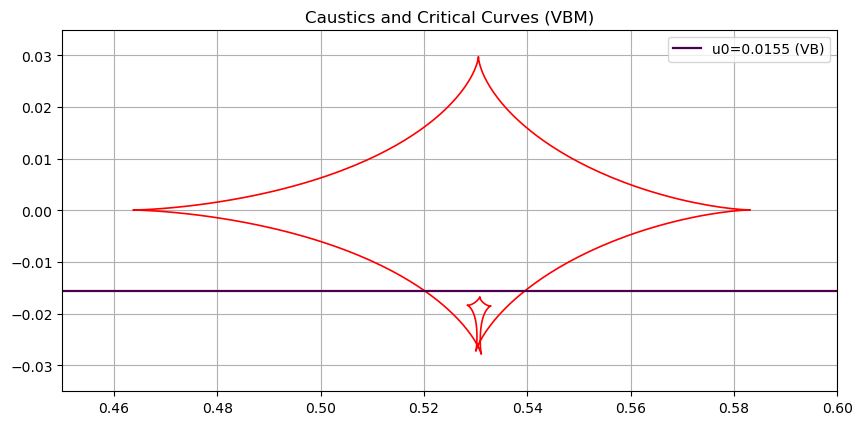

In [51]:
triple_model.plot_caustics_and_critical(show = False)
ax = plt.gca()
ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.035, 0.035)
plt.show()

In [122]:
two_system    = double_model.systems[0]
binary_system = binary_model.systems[0]
three_system  = triple_model.systems[0]

# 2L1S (high-res)
delta_x_two = two_system['cent_x_lc'] - two_system['y1s_lc']
delta_y_two = two_system['cent_y_lc'] - two_system['y2s_lc']

delta_x_two_B = binary_system['cent_x_lc'] - binary_system['y1s_lc']
delta_y_two_B = binary_system['cent_y_lc'] - binary_system['y2s_lc']

# 3L1S (standard res in your build)
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = delta_x_three
delta_y_three = -delta_y_three

In [123]:
# put all models in the same convention
sign_y_triple = -1   # if triple needs y flipped relative to 2L1S/VBM

cent_y3 = sign_y_triple * three_system['cent_y']
y2s3    = sign_y_triple * three_system['y2s']

delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = cent_y3 - y2s3

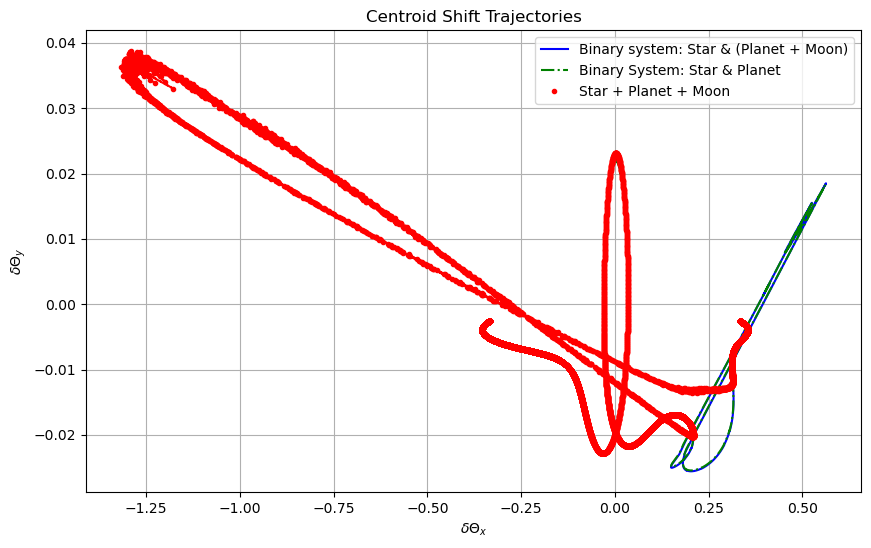

In [124]:
#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two, delta_y_two, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B, delta_y_two_B, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-.')

plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

In [ ]:
delta_triple = (delta_x_three**2 + delta_y_three**2)**0.5
delta_double_A = (delta_x_two**2 + delta_y_two**2)**0.5
delta_double_B = (delta_x_two_B**2 + delta_y_two_B**2)**0.5

#res_triple = delta_double_B - delta_triple
#res_double = delta_double_B - delta_double_A

# bin every 5 data points
#print(delta_double_B.shape[0], delta_triple.shape[0], delta_double_A.shape[0])
triple_resampled = np.zeros_like(delta_double_B)
tau_resampled = np.zeros_like(delta_double_B)
for i in range(int(delta_triple.shape[0]/50)):
    triple_resampled[i] = np.sum(delta_triple[i*50:(i+1)*50])/50.0
    tau_resampled[i] = np.sum(triple_model_tau[i*50:(i+1)*50])/50.0

res_triple = delta_double_B - delta_triple
res_double = delta_double_B - delta_double_A


In [108]:
delta_triple = (delta_x_three**2 + delta_y_three**2)**0.5
delta_double_A = (delta_x_two**2 + delta_y_two**2)**0.5
delta_double_B = (delta_x_two_B**2 + delta_y_two_B**2)**0.5

triple_model_tau_changed = -triple_model_tau

(-0.6, 0.6)

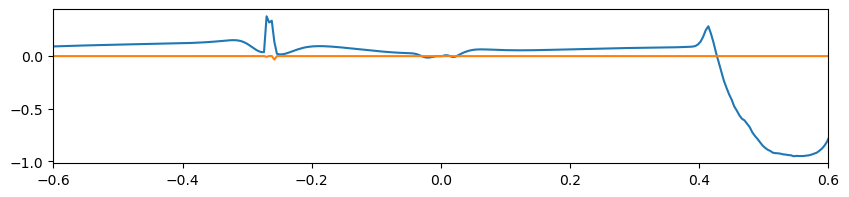

In [90]:
plt.figure(figsize=(10, 2))
plt.plot(tau_resampled, res_triple)  # (triple_model_tau, res_triple)
plt.plot(tau_resampled, res_double)

plt.xlim((-0.6, 0.6))


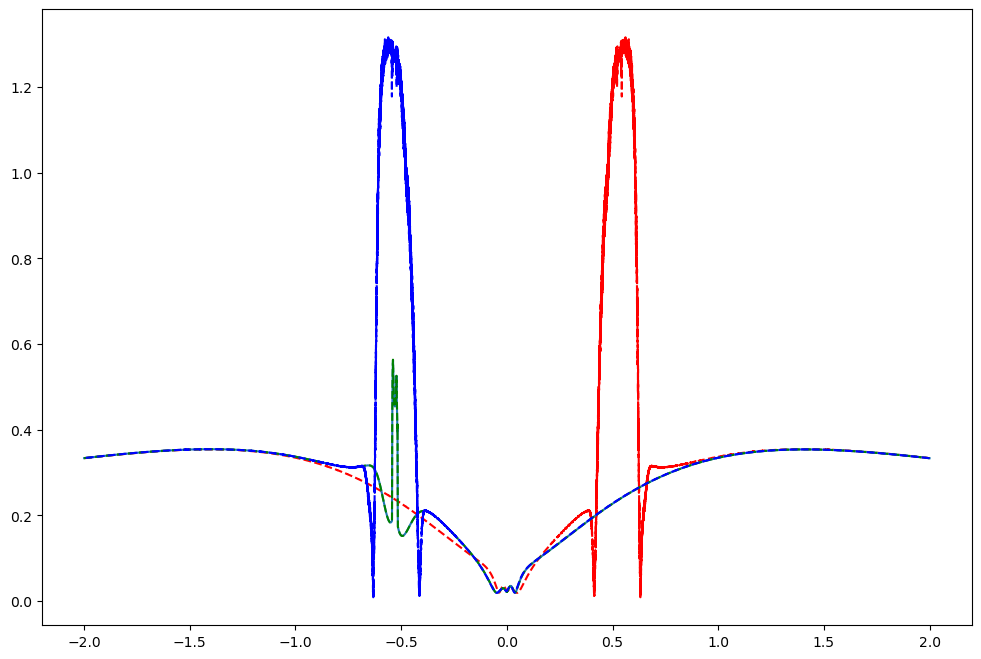

In [134]:
plt.figure(figsize=(12, 8))
plt.plot(triple_model_tau , delta_triple,  'r--')
plt.plot(triple_model_tau, delta_double_B)
plt.plot(triple_model_tau, delta_double_A, 'g--')
plt.plot(triple_model_tau_changed, delta_triple, 'b--')

#plt.xlim((-0.6, -0.5))


In [101]:
len(delta_x_two_B)

1000

# Tweaking some stuff

In [110]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[0.044] #paper

t0 = 0
tE = 20
rho = 0.0018
rs = rho

secnum = 45
basenum = 2
num_points = 400

In [111]:
#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 3, psi, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag

In [112]:
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag

(0.0, 10.0)

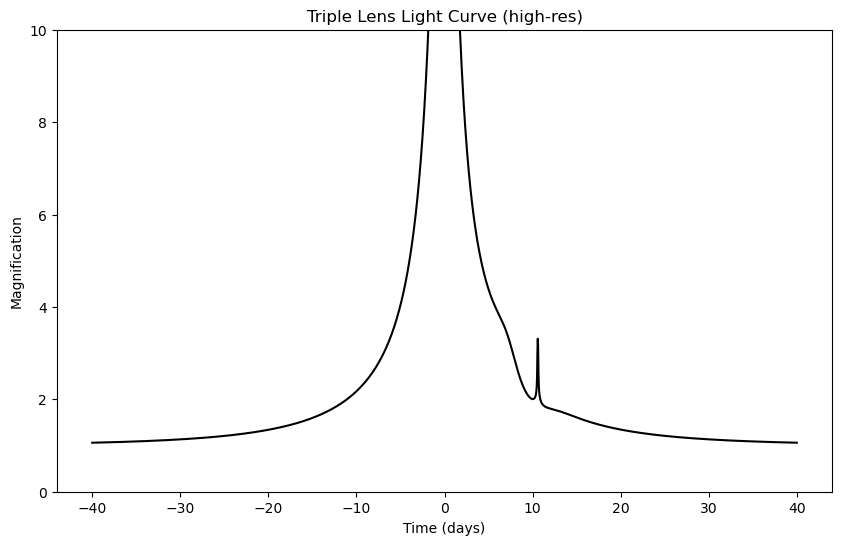

In [115]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_t, triple_model_mag, 'k-')
plt.xlabel('Time (days)')
plt.ylabel('Magnification')
plt.title('Triple Lens Light Curve (high-res)')
#plt.xlim((10, 12))
plt.ylim((0, 10))

u0=0.044 VB y1[:5]=[1.99956185 1.98955053 1.9795392  1.96952788 1.95951656] y2[:5]=[0.06073221 0.06020754 0.05968287 0.0591582  0.05863353]
u0=0.044 analytic y1[:5]=[1.99956185 1.98955053 1.9795392  1.96952788 1.95951656] y2[:5]=[0.06073221 0.06020754 0.05968287 0.0591582  0.05863353]


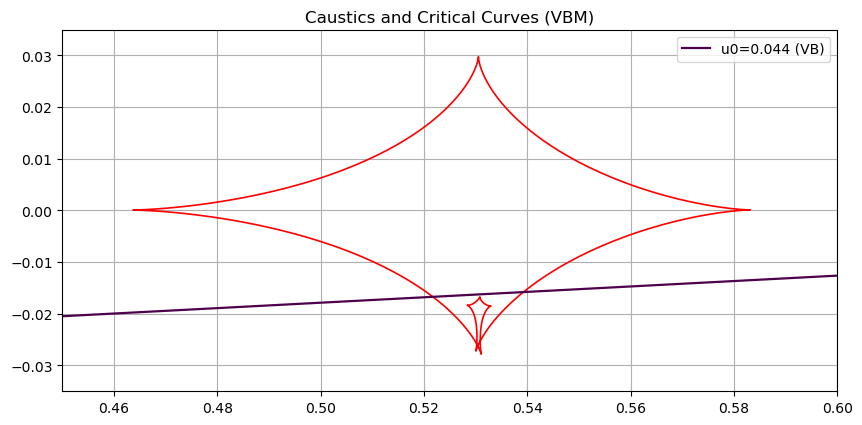

In [114]:
triple_model.plot_caustics_and_critical(show = False)
ax = plt.gca()
ax.set_xlim(0.450, 0.60)
ax.set_ylim(-0.035, 0.035)
plt.show()